# This notebook is outdated!

The parallelizer has recently undergone significant internal restructuring. The contents of this
notebook are partially or fully outdated. A new version will be provided soon.

In [1]:
import iqm.qiskit_iqm as iqm
import matplotlib.pyplot as plt
import qc_parallelizer as parallelizer
from qc_parallelizer import packers
import qiskit
from helpers import patch_qiskit_iqm, plot_circuits, plot_histograms

patch_qiskit_iqm() # you can ignore this

In [2]:
backend = iqm.IQMFakeAphrodite()
print(f"Backend has {backend.num_qubits} qubits.")

Backend has 54 qubits.


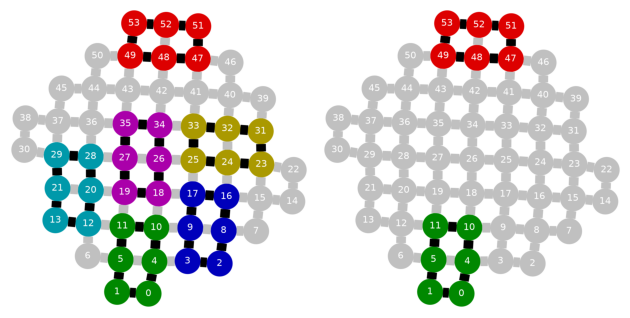

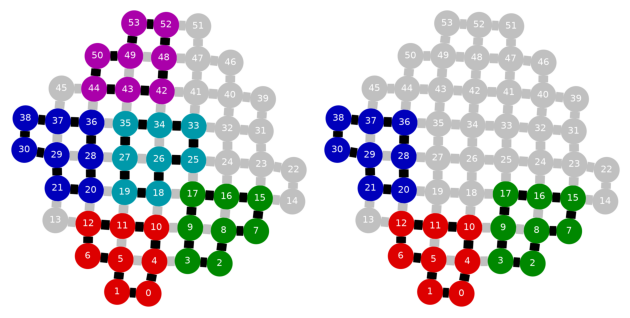

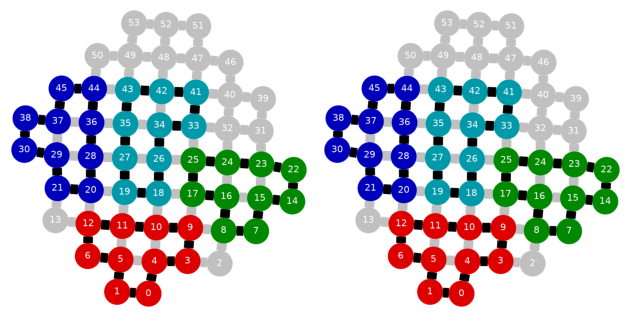

In [3]:
def generate_ring(length: int):
    qc = qiskit.QuantumCircuit(length)
    qc.h(0)
    if length > 1:
        for i in range(length):
            qc.cx(i, (i + 1) % length)
    return qc

for ring_length in [6, 8, 10]:
    circuits = [generate_ring(ring_length) for _ in range(8)]
    rearranged = parallelizer.rearrange(
        circuits,
        backend,
        packer=packers.VF2Packers.Minimizing(),
    )
    display(parallelizer.visualization.plot_placements(rearranged))